In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

2025-08-07 10:24:11.487505: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-07 10:24:11.492982: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-07 10:24:11.554500: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-07 10:24:11.624712: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-07 10:24:11.725255: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

In [3]:
train_path_input = './data'
#test_file_path = '../input/house-prices-advanced-regression-techniques'
test_file_path = train_path_input # eoh
#path_output = '/kaggle/working'
path_output = './working' # eoh

In [4]:
# Define constants for attribute names.
columns = ( # Copied from the input file (./data/train.csv)
  'PassengerId','Survived','Pclass','Name','Sex','Age','SibSp','Parch','Ticket','Fare','Cabin','Embarked'
)
    
# Upper case constants for variables (e.g. C.ID, C._1STFLRSF, C._3SSNPORCH, C.SALEPRICE).
class C:
    @classmethod
    def create(cls, names):
        for name in names:
            const_name = name.upper()
            if name[0].isdigit():
                const_name = '_' + const_name
            setattr(cls, const_name, name)
C.create(columns)
test_columns = [columns[0],*columns[2:]]

In [9]:
# Read in the data.
train_df = pd.read_csv(
    '/'.join([train_path_input,'train.csv']),          # Path to input file.
    header = 0,                                        # Header in line 0.
    names = columns,                                   # Column labels defined.
    index_col = C.PASSENGERID,                         # ID column used for index.
    usecols = columns,                                 # Specify colomns to import.
    skipinitialspace=True,                             # Skip space around ends.
    encoding = "ascii",                                # Assume ascii encoding for input data.
)
test_df = pd.read_csv(
    '/'.join([test_file_path, 'test.csv']),            # Path to input file.
    header = 0,                                        # Header in line 0.
    names = test_columns,                              # Column labels defined.
    index_col = C.PASSENGERID,                         # ID column used for index.
    usecols = test_columns,                            # Specify colomns to import.
    skipinitialspace=True,                             # Skip space around ends.
    encoding = "ascii",                                # Assume ascii encoding for input data.
)

In [10]:
print("Dataset shape:", train_df.shape)
print("\nFirst few rows:")
print(train_df.head())


Dataset shape: (891, 11)

First few rows:
             Survived  Pclass  \
PassengerId                     
1                   0       3   
2                   1       1   
3                   1       3   
4                   1       1   
5                   0       3   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
5                                     Allen, Mr. William Henry    male  35.0   

             SibSp  Parch            Ticket     Fare Cabin Embarked  
PassengerId                                                          
1                1      0

# =============================================================================
# DATA EXPLORATION AND PREPROCESSING
# =============================================================================

In [11]:
def explore_data(df):
    """Explore the dataset structure and missing values"""
    print("Dataset Info:")
    print(df.info())
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nSurvival rate:")
    print(df['Survived'].value_counts(normalize=True))

explore_data(train_df)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB
None

Missing values:
Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

Survival rate:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [12]:
def preprocess_data(train_df, test_df):
    """Clean and preprocess the data for neural network"""
    
    # Combine train and test for consistent preprocessing
    full_data = pd.concat([train_df, test_df], ignore_index=True)
    
    # Fill missing values
    # Age: Fill with median based on Pclass and Sex
    full_data['Age'].fillna(full_data.groupby(['Pclass', 'Sex'])['Age'].transform('median'), inplace=True)
    
    # Embarked: Fill with most common value
    full_data['Embarked'].fillna(full_data['Embarked'].mode()[0], inplace=True)
    
    # Fare: Fill with median based on Pclass
    full_data['Fare'].fillna(full_data.groupby('Pclass')['Fare'].transform('median'), inplace=True)
    
    # Feature engineering
    full_data['FamilySize'] = full_data['SibSp'] + full_data['Parch'] + 1
    full_data['IsAlone'] = (full_data['FamilySize'] == 1).astype(int)
    
    # Extract title from name
    full_data['Title'] = full_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    full_data['Title'] = full_data['Title'].replace(['Lady', 'Countess','Capt', 'Col',
                                                   'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Other')
    full_data['Title'] = full_data['Title'].replace('Mlle', 'Miss')
    full_data['Title'] = full_data['Title'].replace('Ms', 'Miss')
    full_data['Title'] = full_data['Title'].replace('Mme', 'Mrs')
    
    # Age groups
    full_data['AgeGroup'] = pd.cut(full_data['Age'], bins=[0, 12, 18, 35, 60, 100], 
                                  labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])
    
    # Fare groups
    full_data['FareGroup'] = pd.qcut(full_data['Fare'], q=4, labels=['Low', 'Medium', 'High', 'VeryHigh'])
    
    # Encode categorical variables
    le_sex = LabelEncoder()
    full_data['Sex_encoded'] = le_sex.fit_transform(full_data['Sex'])
    
    le_embarked = LabelEncoder()
    full_data['Embarked_encoded'] = le_embarked.fit_transform(full_data['Embarked'])
    
    le_title = LabelEncoder()
    full_data['Title_encoded'] = le_title.fit_transform(full_data['Title'])
    
    le_agegroup = LabelEncoder()
    full_data['AgeGroup_encoded'] = le_agegroup.fit_transform(full_data['AgeGroup'])
    
    le_faregroup = LabelEncoder()
    full_data['FareGroup_encoded'] = le_faregroup.fit_transform(full_data['FareGroup'])
    
    # Select features for the model
    features = ['Pclass', 'Sex_encoded', 'Age', 'SibSp', 'Parch', 'Fare',
                'Embarked_encoded', 'FamilySize', 'IsAlone', 'Title_encoded',
                'AgeGroup_encoded', 'FareGroup_encoded']
    
    # Split back to train and test
    train_processed = full_data[:len(train_df)].copy()
    test_processed = full_data[len(train_df):].copy()
    
    return train_processed, test_processed, features

train_processed, test_processed, features = preprocess_data(train_df, test_df)


# =============================================================================
# PREPARE DATA FOR NEURAL NETWORK
# =============================================================================

In [13]:
# Prepare training data
X = train_processed[features].values
y = train_processed['Survived'].values

# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [14]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Validation set shape: {X_val_scaled.shape}")
print(f"Number of features: {len(features)}")


Training set shape: (712, 12)
Validation set shape: (179, 12)
Number of features: 12


# =============================================================================
# BUILD NEURAL NETWORK MODELS
# =============================================================================

In [15]:
def create_basic_model(input_dim):
    """Create a basic neural network"""
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

def create_advanced_model(input_dim):
    """Create a more sophisticated neural network"""
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        
        layers.Dense(16, activation='relu'),
        layers.Dropout(0.1),
        
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )
    
    return model

# =============================================================================
# TRAIN MODELS
# =============================================================================

In [16]:
# Train basic model
print("Training Basic Neural Network...")
basic_model = create_basic_model(X_train_scaled.shape[1])

# Callbacks for training
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.0001
)

Training Basic Neural Network...


In [17]:
# Train the model
history_basic = basic_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Train advanced model
print("\nTraining Advanced Neural Network...")
advanced_model = create_advanced_model(X_train_scaled.shape[1])

history_advanced = advanced_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.4366 - loss: 0.7674 - val_accuracy: 0.6816 - val_loss: 0.6379 - learning_rate: 0.0010
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7101 - loss: 0.6316 - val_accuracy: 0.7151 - val_loss: 0.5845 - learning_rate: 0.0010
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7503 - loss: 0.5717 - val_accuracy: 0.7821 - val_loss: 0.5265 - learning_rate: 0.0010
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7736 - loss: 0.5162 - val_accuracy: 0.7877 - val_loss: 0.4888 - learning_rate: 0.0010
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7886 - loss: 0.4956 - val_accuracy: 0.7933 - val_loss: 0.4664 - learning_rate: 0.0010
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7783 - loss: 0.4928 - val_accuracy: 0.7989 - val_loss: 0.4566 - learning_rate: 0.0010
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7903 - loss: 0.4723 - 

# =============================================================================
# EVALUATE MODELS
# =============================================================================


Basic Neural Network Evaluation:
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Validation Accuracy: 0.8436

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.88      0.87       110
         1.0       0.81      0.78      0.79        69

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



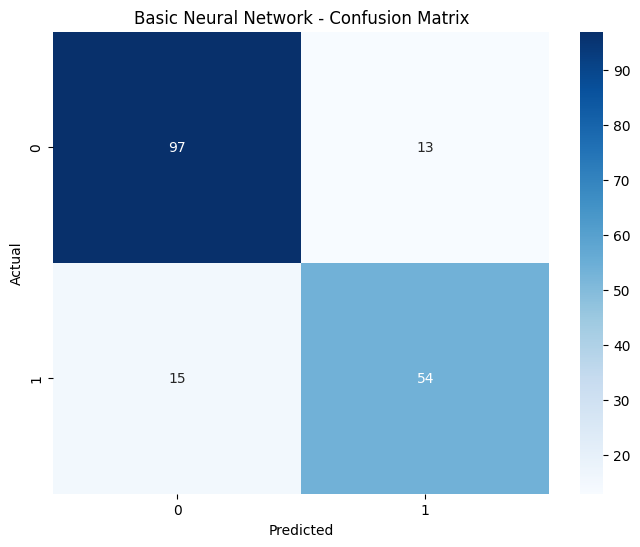


Advanced Neural Network Evaluation:
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step
Validation Accuracy: 0.8603

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.90      0.89       110
         1.0       0.83      0.80      0.81        69

    accuracy                           0.86       179
   macro avg       0.85      0.85      0.85       179
weighted avg       0.86      0.86      0.86       179



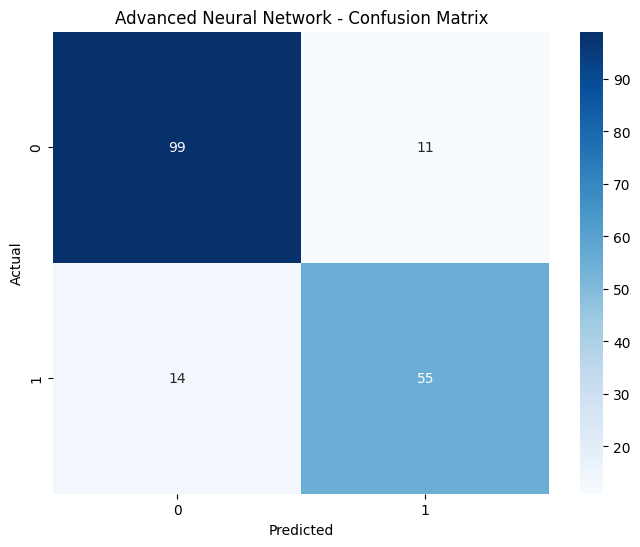

In [18]:
def evaluate_model(model, X_val, y_val, model_name):
    """Evaluate model performance"""
    print(f"\n{model_name} Evaluation:")
    
    # Predictions
    val_pred_prob = model.predict(X_val)
    val_pred = (val_pred_prob > 0.5).astype(int)
    
    # Accuracy
    accuracy = accuracy_score(y_val, val_pred)
    print(f"Validation Accuracy: {accuracy:.4f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_val, val_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_val, val_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    return accuracy

# Evaluate models
basic_accuracy = evaluate_model(basic_model, X_val_scaled, y_val, "Basic Neural Network")
advanced_accuracy = evaluate_model(advanced_model, X_val_scaled, y_val, "Advanced Neural Network")

# =============================================================================
# PLOT TRAINING HISTORY
# =============================================================================

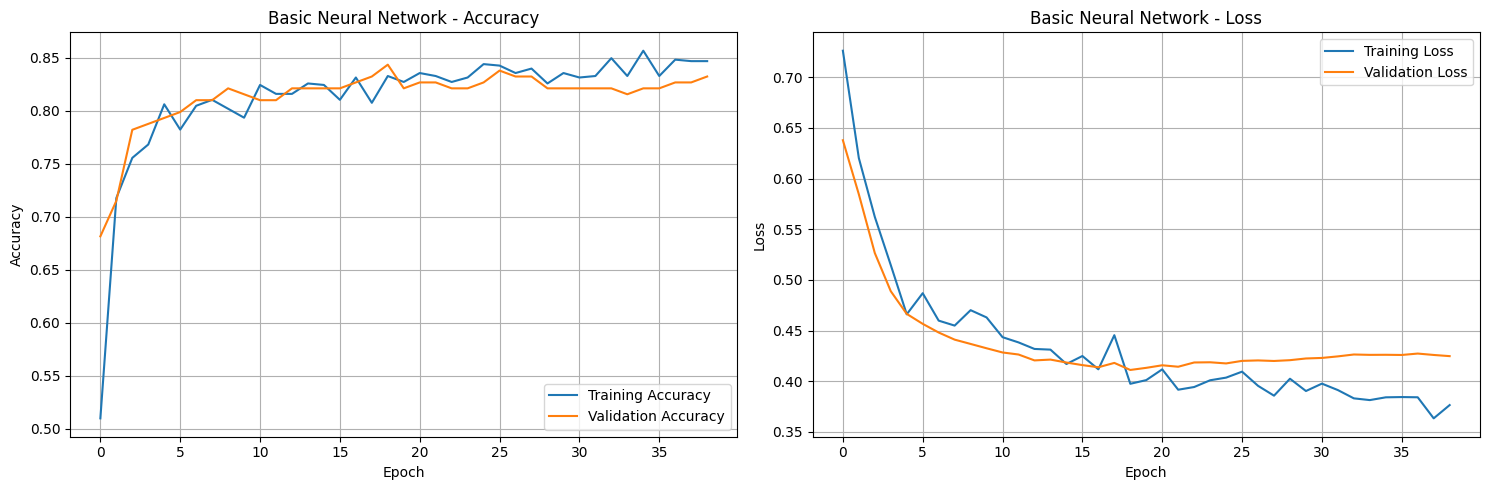

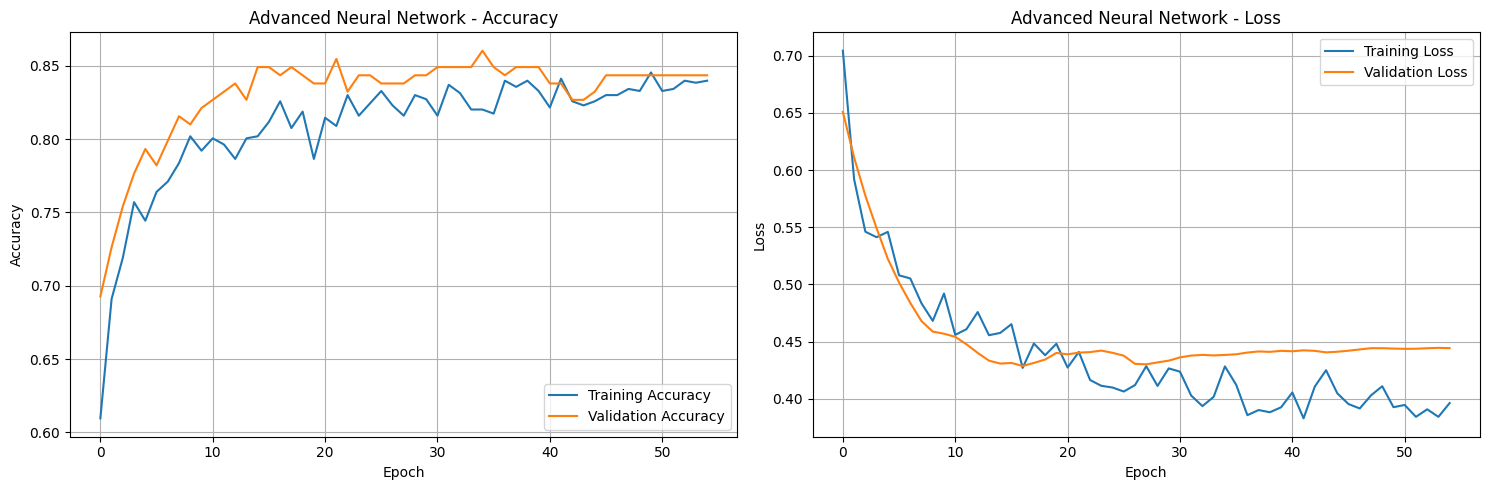

In [19]:
def plot_training_history(history, model_name):
    """Plot training and validation metrics"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot accuracy
    axes[0].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)
    
    # Plot loss
    axes[1].plot(history.history['loss'], label='Training Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history_basic, "Basic Neural Network")
plot_training_history(history_advanced, "Advanced Neural Network")


# =============================================================================
# FEATURE IMPORTANCE ANALYSIS
# =============================================================================


Analyzing Feature Importance...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


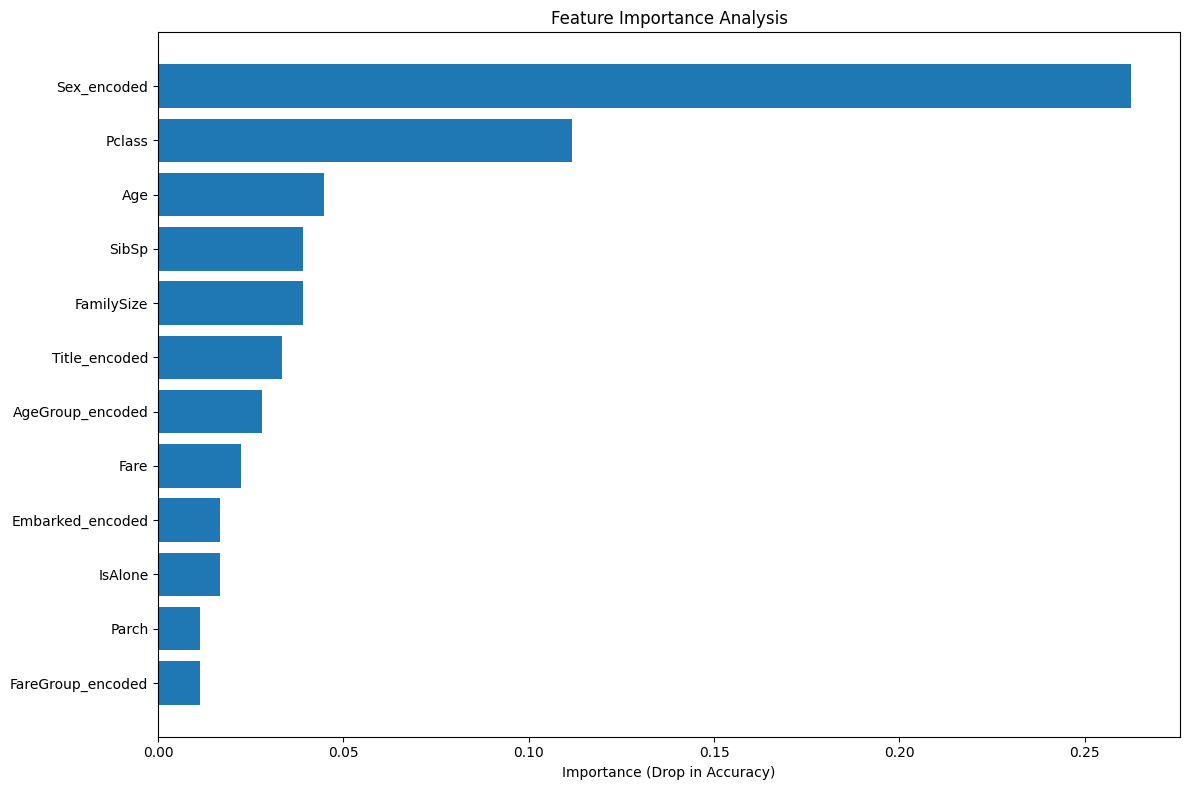


Top 5 Most Important Features:
Sex_encoded: 0.2626
Pclass: 0.1117
Age: 0.0447
SibSp: 0.0391
FamilySize: 0.0391


In [20]:
def analyze_feature_importance(model, feature_names, X_val):
    """Analyze feature importance using permutation"""
    baseline_accuracy = accuracy_score(y_val, (model.predict(X_val) > 0.5).astype(int))
    
    feature_importance = []
    
    for i, feature in enumerate(feature_names):
        # Create a copy of validation data
        X_val_permuted = X_val.copy()
        
        # Permute the feature
        X_val_permuted[:, i] = np.random.permutation(X_val_permuted[:, i])
        
        # Calculate accuracy with permuted feature
        permuted_accuracy = accuracy_score(y_val, (model.predict(X_val_permuted) > 0.5).astype(int))
        
        # Importance is the drop in accuracy
        importance = baseline_accuracy - permuted_accuracy
        feature_importance.append((feature, importance))
    
    # Sort by importance
    feature_importance.sort(key=lambda x: x[1], reverse=True)
    
    # Plot feature importance
    features_sorted, importance_sorted = zip(*feature_importance)
    
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(features_sorted)), importance_sorted)
    plt.yticks(range(len(features_sorted)), features_sorted)
    plt.xlabel('Importance (Drop in Accuracy)')
    plt.title('Feature Importance Analysis')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return feature_importance

print("\nAnalyzing Feature Importance...")
feature_importance = analyze_feature_importance(advanced_model, features, X_val_scaled)

print("\nTop 5 Most Important Features:")
for feature, importance in feature_importance[:5]:
    print(f"{feature}: {importance:.4f}")

# =============================================================================
# PREPARE SUBMISSION
# =============================================================================

In [27]:
def prepare_submission(model, test_processed, features, scaler):
    """Prepare submission file for Kaggle"""
    
    # Prepare test data
    X_test = test_processed[features].values
    X_test_scaled = scaler.transform(X_test)
    
    # Make predictions
    test_predictions = model.predict(X_test_scaled)
    test_predictions = (test_predictions > 0.5).astype(int).flatten()
    
    # Create submission dataframe
    submission = pd.DataFrame({
        C.PASSENGERID: test_processed.index+1,
        C.SURVIVED: test_predictions
    })
    
    # Save to 
    output_file = 'titanic_neural_network_submission.csv'
    path = '/'.join([path_output, output_file])
    submission.to_csv(path, index=False)
    print(f"Submission file saved as {path}")
    
    return submission

# Create submission with the best model
if advanced_accuracy > basic_accuracy:
    submission = prepare_submission(advanced_model, test_processed, features, scaler)
    print(f"Using Advanced Neural Network (Accuracy: {advanced_accuracy:.4f})")
else:
    submission = prepare_submission(basic_model, test_processed, features, scaler)
    print(f"Using Basic Neural Network (Accuracy: {basic_accuracy:.4f})")

print("\nSubmission Preview:")
print(submission.head(10))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Submission file saved as ./working/titanic_neural_network_submission.csv
Using Advanced Neural Network (Accuracy: 0.8603)

Submission Preview:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         0
9          901         0


# =============================================================================
# SUMMARY AND TIPS
# =============================================================================

In [22]:
print("\n" + "="*60)
print("NEURAL NETWORK MODELING SUMMARY")
print("="*60)
print(f"Basic Neural Network Accuracy: {basic_accuracy:.4f}")
print(f"Advanced Neural Network Accuracy: {advanced_accuracy:.4f}")
print(f"Total Features Used: {len(features)}")
print(f"Training Set Size: {len(X_train)}")
print(f"Validation Set Size: {len(X_val)}")

print("\nKey Techniques Used:")
print("1. Feature Engineering (FamilySize, IsAlone, Title extraction)")
print("2. Data Preprocessing (Missing value imputation, encoding)")
print("3. Feature Scaling (StandardScaler)")
print("4. Dropout Layers (Regularization)")
print("5. Batch Normalization (Advanced model)")
print("6. Early Stopping (Prevent overfitting)")
print("7. Learning Rate Reduction")
print("8. Feature Importance Analysis")

print("\nTips for Improvement:")
print("1. Try ensemble methods (combine multiple models)")
print("2. Hyperparameter tuning with Keras Tuner")
print("3. Cross-validation for more robust evaluation")
print("4. Additional feature engineering")
print("5. Try different architectures (wider/deeper networks)")
print("6. Experiment with different activation functions")


NEURAL NETWORK MODELING SUMMARY
Basic Neural Network Accuracy: 0.8436
Advanced Neural Network Accuracy: 0.8603
Total Features Used: 12
Training Set Size: 712
Validation Set Size: 179

Key Techniques Used:
1. Feature Engineering (FamilySize, IsAlone, Title extraction)
2. Data Preprocessing (Missing value imputation, encoding)
3. Feature Scaling (StandardScaler)
4. Dropout Layers (Regularization)
5. Batch Normalization (Advanced model)
6. Early Stopping (Prevent overfitting)
7. Learning Rate Reduction
8. Feature Importance Analysis

Tips for Improvement:
1. Try ensemble methods (combine multiple models)
2. Hyperparameter tuning with Keras Tuner
3. Cross-validation for more robust evaluation
4. Additional feature engineering
5. Try different architectures (wider/deeper networks)
6. Experiment with different activation functions
